# Inference on test set

Uses fitted parameters (from `fit-model.ipynb`) and the mixture Gibbs sampler
to infer $z$ and $C$ for every test home from **total load alone**.

**C update**: each Gibbs iteration, C is sampled from
$\mathrm{Bernoulli}(\mathrm{logistic}(\text{transitions/day from }z))$.
This replaces the broken 'any $z\neq\mathrm{off}\Rightarrow C=1$' rule:
with $D\approx360$ days, $P(z=\text{all-off})\approx0.25^{360}\approx0$,
so that rule fires on every home. Transitions/day captures sustained charging
blocks (EV) vs scattered HMM artefacts (non-EV).


In [25]:
import sys
from pathlib import Path
repo_root = str(Path('.').resolve().parents[1])
utils_dir = str(Path('.').resolve().parents[1] / 'notebooks' / 'utils')
for p in [repo_root, utils_dir]:
    if p not in sys.path: sys.path.insert(0, p)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models import graphical_model as gm
from models import first_diff_logistic as fdl
import convergence_plots as cvg
import background_plots as bgp


## 1. Load fitted parameters

In [26]:
params = pickle.load(open('../../models/fitted_params-milestone4-rank5.pkl', 'rb'))
print(params.summary())


ModelParams summary
----------------------------------------
EV States
  p_C                 = 0.1667
  pi_z                = [0.8304 0.0419 0.1276]
  P_z (rows sum to 1):
      off: [0.9875 0.0085 0.004 ]
      low: [0.3498 0.515  0.1352]
     high: [0.0232 0.1294 0.8474]

EV Charging Magnitudes
  Theta[ off]: mu=+0.0000, sigma_Theta=0.0000, sigma^EV=0.0010
  Theta[ low]: mu=+0.8727, sigma_Theta=0.1326, sigma^EV=0.4859
  Theta[high]: mu=+3.5616, sigma_Theta=0.6219, sigma^EV=0.7378

Non-EV — hierarchical eta prior
  eta_bar             (min=+0.617, median=+0.947, max=+1.326, mean=+0.957)
  W_eta               shape=(T=96, r=5)
  psi_eta             (per-t residual variance: min=0.0000, median=0.0043, max=0.0187)

Non-EV — hierarchical omega prior (InvGamma per t)
  a_omega             (shape: min=2.34, median=2.68, max=3.34)
  b_omega             (rate:  min=0.4757, median=1.3029, max=3.0032)
  E[(omega_t)^2]      (prior mean: min=0.3211, median=0.8097, max=1.4279)


## 2. Train set + heuristic baseline

Fit the logistic model on train homes (to use for warm-starting and baseline comparison).

In [27]:
def load_split(pkl_path: str) -> pd.DataFrame:
    raw = pickle.load(open(pkl_path, 'rb'))
    df = pd.concat(
        [d.assign(home_id=h, has_ev=ev, city=c)
         for h, (ev, c, d) in raw.items()]
    ).reset_index()
    df.rename(columns={'car1': 'ev_load', 'load': 'total_load'}, inplace=True)
    df['day']        = df['localminute'].dt.normalize()
    df['time']       = df['localminute'].dt.strftime('%H:%M')
    df               = df.drop(columns='localminute')
    df['time']       = pd.to_timedelta(df['time'] + ':00')
    df['time_index'] = (df['time'].dt.total_seconds() // (15 * 60)).astype(int)
    df['charge_state'] = df['charge_state'].astype('int')
    mask = (df.groupby(['home_id', 'day'])['time_index']
              .transform(lambda x: x.nunique() == 96))
    return df[mask]

train_df = load_split('../../data_processing/splits/train.pkl')
print(f'Train: {train_df.home_id.nunique()} homes, '
      f'{train_df["has_ev"].map(int).groupby(train_df["home_id"]).first().sum()} EV')


Train: 54 homes, 9 EV


In [28]:
homes_train = gm.build_heuristic_homes(train_df)
logistic_model, w, lo, hi, md = fdl.tune(homes_train)
print(f'Heuristic tuned: window={w*15}min  low={lo:.2f}  high={hi:.2f}  max_dur={md}')


Best: window=6 (90 min), low=1.2, high=1.6, max_duration=16 (240 min)  (train avg precision=0.5502)
Heuristic tuned: window=90min  low=1.20  high=1.60  max_dur=16


## 3. Load test set and run heuristic warm-start

The heuristic is used **only** to warm-start C and z (shortening burn-in).
Inference itself sees only `total_load`.

In [29]:
test_df = load_split('../../data_processing/splits/test.pkl')
print(f'Test: {test_df.home_id.nunique()} homes, '
      f'{test_df["has_ev"].map(int).groupby(test_df["home_id"]).first().sum()} EV')
test_df.groupby('home_id')['has_ev'].first().value_counts().rename('count').to_frame()


Test: 18 homes, 3 EV


,count
has_ev,
False,15
True,3


In [30]:
# Run heuristic on test homes to get warm-start C and z values
homes_test = gm.build_heuristic_homes(test_df)
heuristic_summary_test, heuristic_states_test = fdl.predict(
    logistic_model, homes_test, w, lo, hi, md
)
heuristic_summary_test['C_hat'] = (heuristic_summary_test['p_hat'] >= 0.5).astype(int)

heuristic_c_probs = dict(zip(
    heuristic_summary_test['dataid'].astype(int),
    heuristic_summary_test['p_hat'].astype(float),
))
heuristic_c_hat = dict(zip(
    heuristic_summary_test['dataid'].astype(int),
    heuristic_summary_test['C_hat'].astype(int),
))

# Build initial z from heuristic state estimates (1-D flat → (D,T))
init_z_dict = {}
for hid, z_flat in heuristic_states_test.items():
    g = test_df[test_df['home_id'] == hid]
    D = g['day'].nunique()
    init_z_dict[int(hid)] = z_flat[:D * 96].reshape(D, 96)

print('Heuristic predictions on test homes:')
print(heuristic_summary_test.to_string(index=False))


Heuristic predictions on test homes:
 dataid  has_ev  transitions_per_day  p_hat  C_hat
    142       0                0.000  0.152      0
   1222       1                3.295  0.933      1
   1417       0                0.590  0.281      0
   1642       1                2.264  0.782      1
   2318       0                0.219  0.193      0
   3517       0                0.033  0.158      0
   4495       0                0.000  0.152      0
   5587       0                0.514  0.261      0
   5679       1                1.978  0.710      1
   5746       0                0.000  0.152      0
   7114       0                0.389  0.230      0
   7800       0                1.151  0.451      0
   8061       0                0.393  0.232      0
   8386       0                0.064  0.163      0
   8565       0                0.689  0.308      0
   9019       0                0.042  0.159      0
   9160       0                0.081  0.166      0
   9775       0                0.000  0.152  

## 4. Gibbs inference on all test homes

In [ ]:
# ── CONFIGURE ──────────────────────────────────────────────────────────────
S_BURN   = 200
S_RETAIN = 500
SEED     = 0
HOME_IDS = [1222, 1417]
# ───────────────────────────────────────────────────────────────────────────


In [38]:
print(test_df)
print(heuristic_c_hat)
print(init_z_dict)

        total_load  ev_load  charge_state  non_ev_load  home_id  has_ev  \
76        0.771467     0.44             1     0.331467     5679    True   
77        7.445000     6.82             2     0.625000     5679    True   
78        7.400200     6.78             2     0.620200     5679    True   
79        7.388667     6.79             2     0.598667     5679    True   
80        7.254333     6.77             2     0.484333     5679    True   
...            ...      ...           ...          ...      ...     ...   
505923    0.641333     0.00             0     0.641333     8386   False   
505924    0.512400     0.00             0     0.512400     8386   False   
505925    0.615400     0.00             0     0.615400     8386   False   
505926    0.971067     0.00             0     0.971067     8386   False   
505927    0.915933     0.00             0     0.915933     8386   False   

           city                       day            time  time_index  
76      newyork 2019-05-02 

In [ ]:
_ids         = set(HOME_IDS)
test_df_sub  = test_df[test_df['home_id'].isin(_ids)]
init_c_sub   = {k: v for k, v in heuristic_c_hat.items() if k in _ids}
init_z_sub   = {k: v for k, v in init_z_dict.items()     if k in _ids}

inferences = gm.infer_all(
    test_df_sub, params,
    S_burn=S_BURN, S=S_RETAIN, seed=SEED,
    verbose=True,
    initial_c_dict=init_c_sub,
    initial_z_dict=init_z_sub,
    c_logistic_model=logistic_model,   # used for C sampling in Block 2
)


KeyError: slice(None, 1, None)

## 5. z confusion matrices

Per-home row-normalised confusion, then averaged over homes. Separate for EV and non-EV. Hard (MAP) and soft (posterior) versions for Gibbs; hard only for heuristic baseline.

In [9]:
# Build C-probability dicts
c_probs_gibbs    = {hid: float(inf.c_samples.mean())    for hid, inf in inferences.items()}
c_probs_baseline = dict(heuristic_c_probs)

# MAP-z → heuristic: count transitions/day in the Gibbs MAP z, then apply the
# tuned logistic model (same one used for the heuristic baseline).
c_probs_map_z_heur = {}
for hid, inf in inferences.items():
    z_flat = inf.z_hat.ravel()                           # MAP z, shape (D*96,)
    rate   = float((np.diff(z_flat) != 0).sum()) / (len(z_flat) / 96)
    c_probs_map_z_heur[hid] = float(logistic_model.predict_proba([[rate]])[0, 1])

c_prob_methods = {
    'gibbs':           c_probs_gibbs,
    'baseline':        c_probs_baseline,
    'map_z+heuristic': c_probs_map_z_heur,
}

results = gm.evaluate(
    test_df_sub, inferences,
    c_prob_methods   = c_prob_methods,
    heuristic_states = heuristic_states_test,
)

# Print z confusion tables only
from models.graphical_model import STATE_NAMES
SEP = '─' * 64

def fmt_row(label, row):
    cells = '  '.join(f'{"NaN":>7}' if np.isnan(v) else f'{v:>7.3f}' for v in row)
    return f'  {label:<8} {cells}'

for group, home_ids, hard_cm, soft_cm, heur_cm in [
    ('EV (C_true=1)',     results['ev_home_ids'],     results['ev_z_hard'],     results['ev_z_soft'],     results['ev_z_heur']),
    ('non-EV (C_true=0)', results['non_ev_home_ids'], results['non_ev_z_hard'], results['non_ev_z_soft'], results['non_ev_z_heur']),
]:
    n = len(home_ids)
    print(f'\n{SEP}')
    print(f'z confusion — {group}  (N={n} homes)')
    print(f'Aggregation: per-home row-normalised CM averaged over {n} homes  |  rows=true, cols=pred')
    header = f'  {"":8}  {"off":>7}  {"low":>7}  {"high":>7}'
    for cm, variant in [(hard_cm, 'hard Gibbs'), (soft_cm, 'soft Gibbs'), (heur_cm, 'hard heuristic')]:
        if cm is None: continue
        print(f'\n  [{variant}]')
        print(header)
        for k, name in enumerate(STATE_NAMES):
            print(fmt_row(name, cm[k]))



────────────────────────────────────────────────────────────────
z confusion — EV (C_true=1)  (N=3 homes)
Aggregation: per-home row-normalised CM averaged over 3 homes  |  rows=true, cols=pred

  [hard Gibbs]
                off      low     high
  off        0.758    0.181    0.062
  low        0.244    0.551    0.206
  high       0.003    0.032    0.965

  [soft Gibbs]
                off      low     high
  off        0.753    0.184    0.063
  low        0.246    0.539    0.216
  high       0.006    0.037    0.957

  [hard heuristic]
                off      low     high
  off        0.924    0.035    0.041
  low        0.733    0.066    0.201
  high       0.128    0.051    0.821

────────────────────────────────────────────────────────────────
z confusion — non-EV (C_true=0)  (N=15 homes)
Aggregation: per-home row-normalised CM averaged over 15 homes  |  rows=true, cols=pred

  [hard Gibbs]
                off      low     high
  off        0.742    0.120    0.138
  low          N

/Users/jackhsieh/Downloads/residential-power-forecasting/models/graphical_model.py:1390: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(cm_list, axis=0), axis=0)


## 6. C confusion matrices

Hard (threshold 0.5) and soft ($\hat P$ as fraction), row-normalised, averaged over homes.

In [13]:
gm.print_evaluation({'ev_home_ids':[], 'non_ev_home_ids':[], 'ev_z_hard':None,
    'ev_z_soft':None, 'ev_z_heur':None, 'non_ev_z_hard':None,
    'non_ev_z_soft':None, 'non_ev_z_heur':None,
    'c_results': results['c_results']})



────────────────────────────────────────────────────────────────
z confusion — EV homes (C_true=1)  (N=0 homes)
  Aggregation: per-home row-normalised CM, then mean over 0 homes
  Rows = true state, columns = predicted state

────────────────────────────────────────────────────────────────
z confusion — non-EV homes (C_true=0)  (N=0 homes)
  Aggregation: per-home row-normalised CM, then mean over 0 homes
  Rows = true state, columns = predicted state
  Note: rows 'low' and 'high' are NaN (no ground-truth examples)

────────────────────────────────────────────────────────────────
C confusion — method: gibbs
  Aggregation: row-normalised CM averaged over 18 homes
  (3 EV, 15 non-EV)  accuracy=0.1667
  Rows = true C, columns = predicted C

  [hard (threshold 0.5)]
              no-EV       EV
  no-EV      0.000    1.000
  EV         0.000    1.000

  [soft (P̂ as fraction)]
              no-EV       EV
  no-EV      0.020    0.980
  EV         0.000    1.000

─────────────────────────────

## 7. Convergence diagnostics (one EV home)

In [14]:
ev_hids = [hid for hid in inferences
           if bool(test_df_sub[test_df_sub['home_id']==hid]['has_ev'].iloc[0])]
diag_hid = ev_hids[0] if ev_hids else next(iter(inferences))
print(f'Showing convergence for home {diag_hid}')

# Re-run with record_traces=True if not already stored
# (infer_all sets record_traces=True by default — we check)
inf_diag = inferences[diag_hid]
if inf_diag.alpha_trace is not None:
    figs = cvg.plot_all_diagnostics(inf_diag)
    for fig in figs:
        plt.show()
else:
    print('Traces not recorded (record_traces=False in infer_home call).')


Showing convergence for home 1222


AttributeError: 'HomeInference' object has no attribute 'alpha_trace'

## 8. Posterior z heatmaps — one EV home, one non-EV home

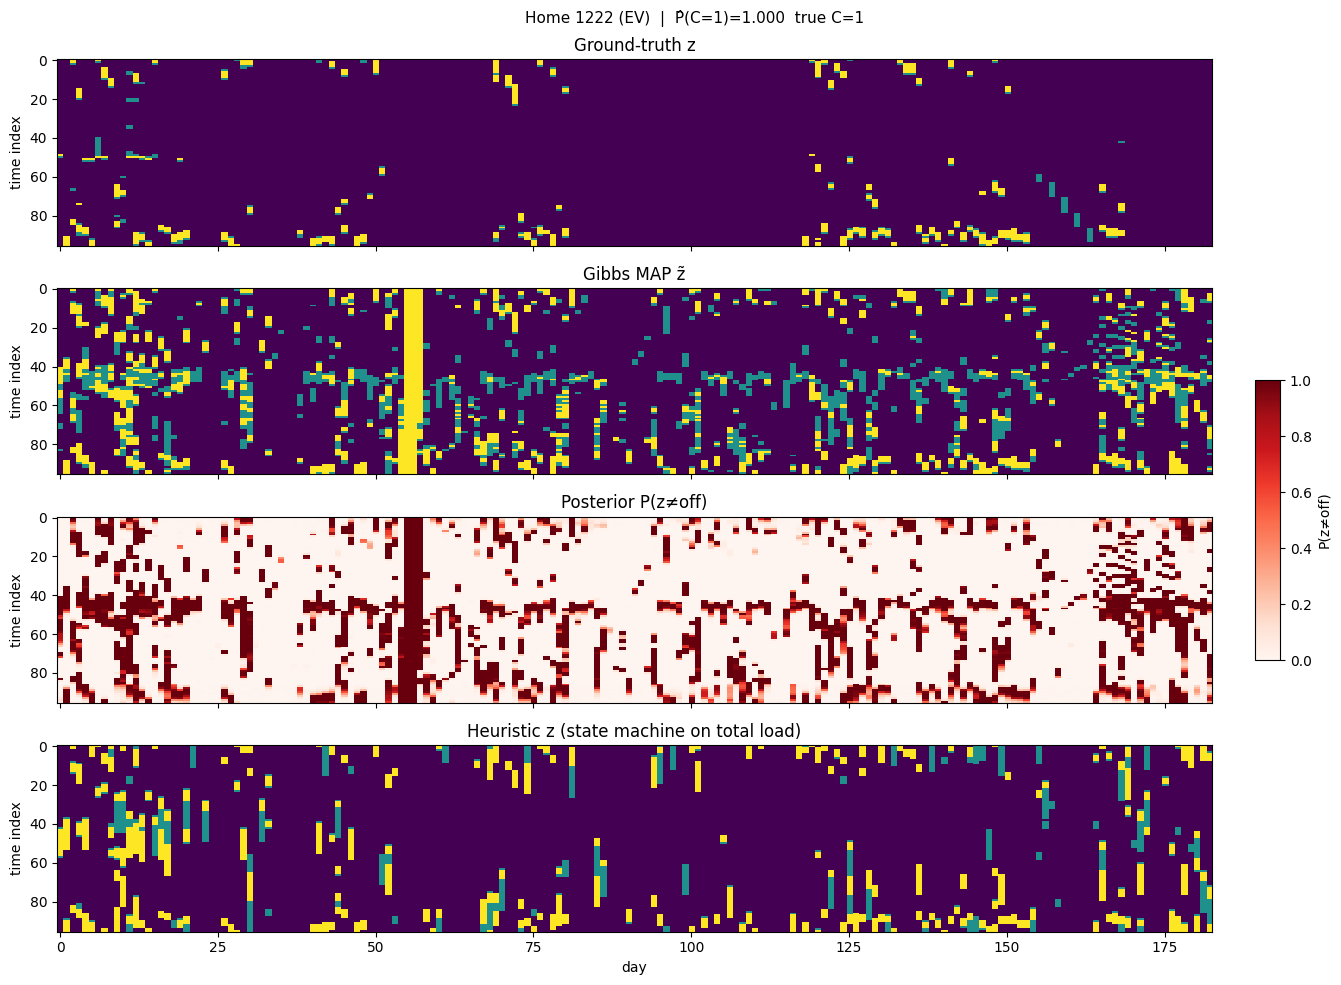

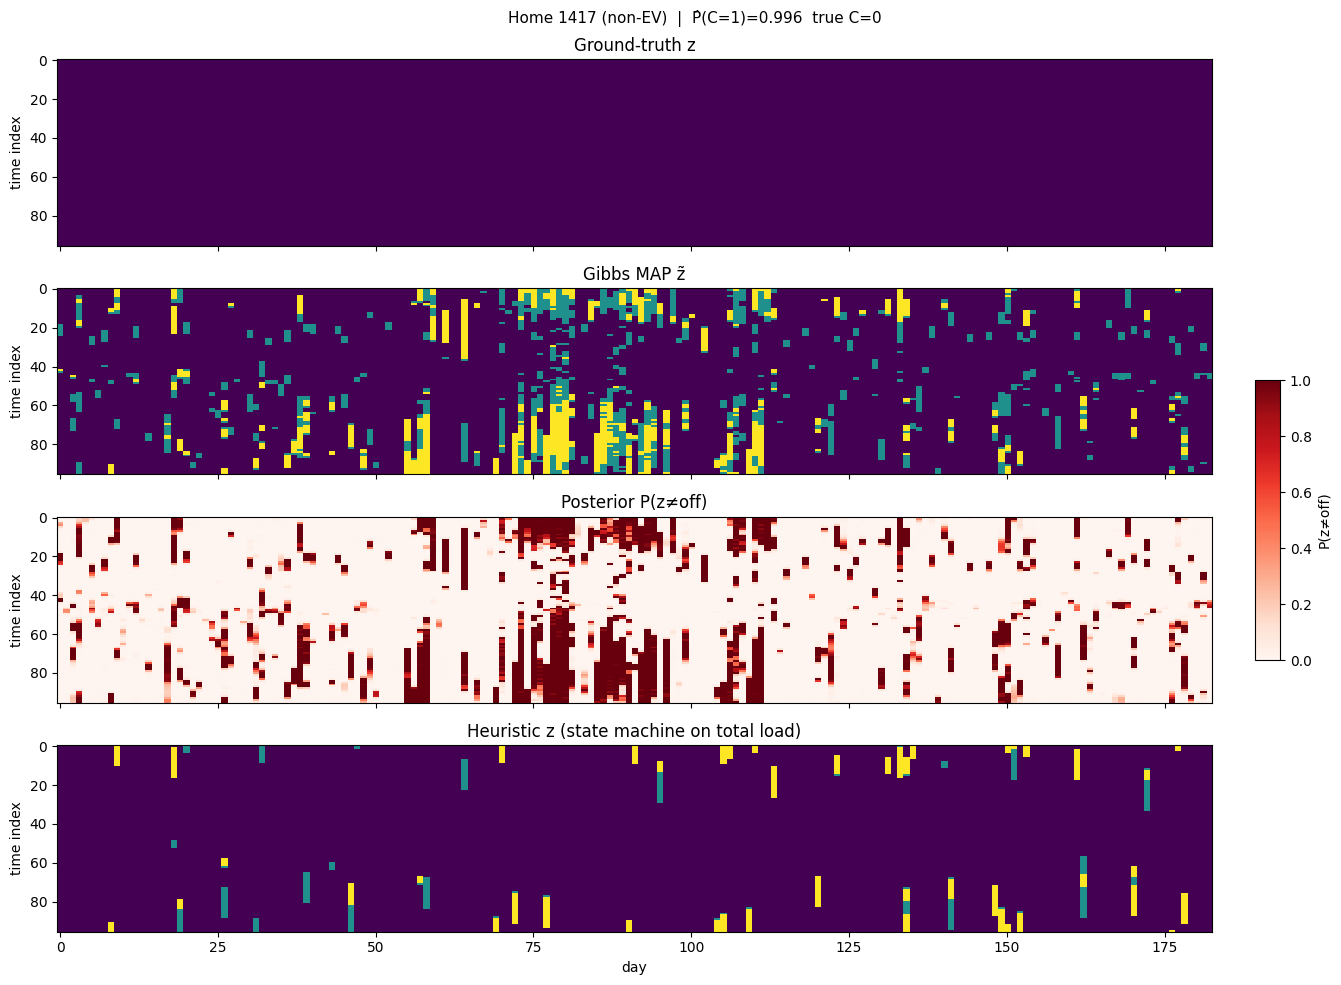

In [15]:
non_ev_hids = [hid for hid in inferences
               if not bool(test_df_sub[test_df_sub['home_id']==hid]['has_ev'].iloc[0])]

for hid, label in [(ev_hids[0], 'EV'), (non_ev_hids[0], 'non-EV')]:
    g    = test_df_sub[test_df_sub['home_id']==hid].sort_values(['day','time_index'])
    D    = g['day'].nunique()
    z_tr = g['charge_state'].to_numpy().reshape(D, 96)
    inf  = inferences[hid]
    heur = heuristic_states_test.get(hid, np.zeros(D*96, dtype=int))[:D*96].reshape(D, 96)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Home {hid} ({label})  |  P̂(C=1)={inf.c_samples.mean():.3f}  '
                 f'true C={int(g["has_ev"].iloc[0])}', fontsize=11)

    axes[0].imshow(z_tr.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[0].set_title('Ground-truth z'); axes[0].set_ylabel('time index')

    axes[1].imshow(inf.z_hat.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[1].set_title('Gibbs MAP z̃'); axes[1].set_ylabel('time index')

    p_chg = 1.0 - inf.z_marginals[:,:,0]
    im = axes[2].imshow(p_chg.T, aspect='auto', cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    axes[2].set_title('Posterior P(z≠off)'); axes[2].set_ylabel('time index')

    axes[3].imshow(heur.T, aspect='auto', cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[3].set_title('Heuristic z (state machine on total load)')
    axes[3].set_xlabel('day'); axes[3].set_ylabel('time index')

    # Reserve a strip on the right for the colorbar without disturbing any subplot width
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    cbar_ax = fig.add_axes([0.90, 0.33, 0.018, 0.28])
    fig.colorbar(im, cax=cbar_ax, label='P(z≠off)')

    plt.show()


## 9. Diagnostic: inferred posterior vs ground-truth $x^{\mathrm{Non\text{-}EV}}$

For one home, compare the inferred $\eta^{(n)}$ and $\omega^{(n)}$ posteriors
to the empirical mean/std of the true non-EV signal (which the model never
sees at inference time). Three panels: mean profile, std profile, and the
per-timestep z-error rates (FP = predicting charging when truly off; FN =
the reverse). When inference over-predicts EV charging, this plot localizes
**where** in the day the misattribution happens — typically at times where
inferred $\eta$ falls below the true non-EV mean (the residual $x - \eta_{\text{inferred}}$
is positive, the sampler attributes it to a charging state instead of $\omega$).

In [24]:
# Pick a home to diagnose. Default: first EV home with at least some
# false positives (i.e. where the over-prediction is visible).
diag_home_id = ev_hids[0] if 'ev_hids' in dir() and len(ev_hids) else \
               next(iter(inferences))
print(f'Diagnosing home {diag_home_id}')

fig_diag = bgp.plot_inference_vs_truth(
    test_df  = test_df_sub,
    inference = inferences[diag_home_id],
    params    = params,
    home_id   = diag_home_id,
)
plt.show()

Diagnosing home 1222


NameError: name 'bgp' is not defined